In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 15:21:55.309209: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 15:21:55.373322: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
path = '/ix1/ylee/Yifan_Zhang/Code_data/Tumor/MOC/'

# Gene analysis

In [3]:
adata_ori = sc.read_h5ad(path+'GSE273507_combined.h5ad')
adata_ori.var_names_make_unique()

In [131]:
adata = adata_ori.copy()
adata

AnnData object with n_obs × n_vars = 26926 × 32285
    obs: 'batch'

In [132]:
adata.obs['batch']

AAACCCAAGCACTCGC-1    control 1
AAACCCAAGCGTCTCG-1    control 1
AAACCCAAGGATTCAA-1    control 1
AAACCCAGTACTTGTG-1    control 1
AAACCCATCACCATAG-1    control 1
                        ...    
TTTGGTTTCCTCTAAT-1        ASO 3
TTTGGTTTCTGTCCGT-1        ASO 3
TTTGTTGAGTGCGACA-1        ASO 3
TTTGTTGGTCCAGGTC-1        ASO 3
TTTGTTGGTTCACGAT-1        ASO 3
Name: batch, Length: 26926, dtype: category
Categories (6, object): ['ASO 1', 'ASO 2', 'ASO 3', 'control 1', 'control 2', 'control 3']

In [133]:
suffix_map = {
    'ASO 1': 'ASO_1', 'ASO 2': 'ASO_2', 'ASO 3': 'ASO_3',
    'control 1': 'CT_1', 'control 2': 'CT_2', 'control 3': 'CT_3'
}
adata.obs_names = adata.obs_names + '-' + adata.obs['batch'].astype(str).map(suffix_map)

In [134]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)


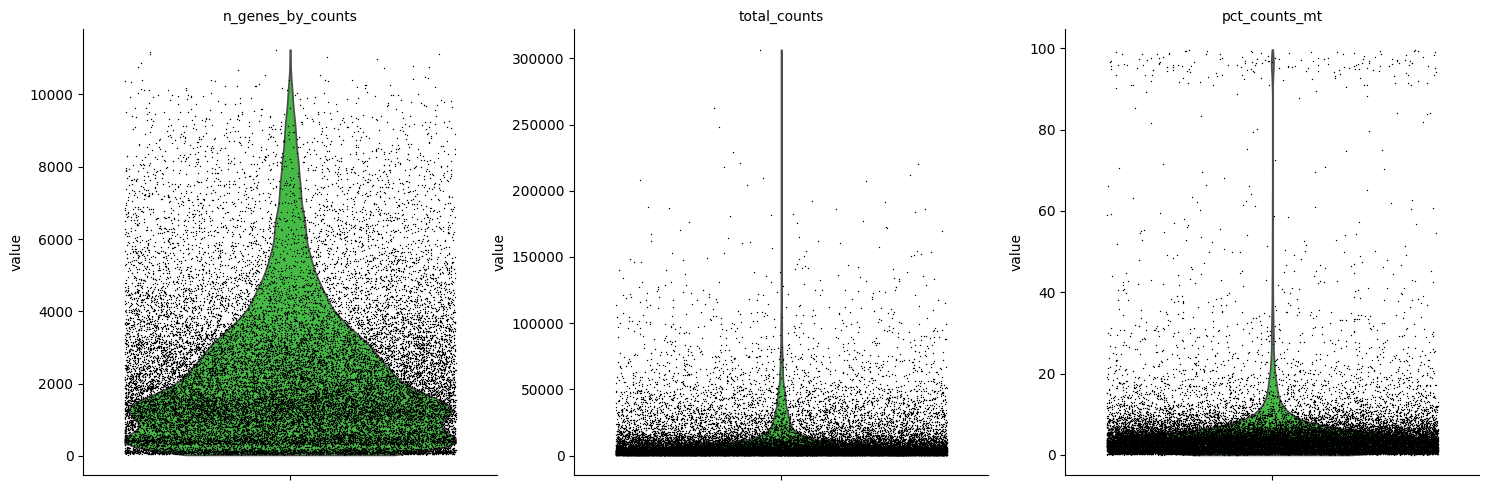

In [135]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    color='limegreen',
)

In [136]:
sc.pp.filter_cells(adata, min_genes= 300)
sc.pp.filter_cells(adata, max_genes= 12000)

sc.pp.filter_cells(adata, min_counts=1000)
sc.pp.filter_cells(adata, max_counts=80000)

sc.pp.filter_genes(adata, min_cells=50)

In [137]:
sc.pp.scrublet(adata)
adata = adata[adata.obs['predicted_doublet'] == False]

In [138]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,  n_top_genes=2500, )

In [139]:
adata = adata[adata.obs['pct_counts_mt'] < 30]
adata = adata[:, adata.var['highly_variable']]

In [140]:
adata

View of AnnData object with n_obs × n_vars = 21116 × 2500
    obs: 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'hvg'

In [141]:
def lR_to_l(adata, mapper={'leiden_R': 'leiden'}):
    for current_col_name in mapper:
        new_col_name = mapper[current_col_name]
        current_col = adata.obs[current_col_name].copy()
        adata.obs.drop(columns=current_col_name)
        adata.obs[new_col_name] = current_col
    return

def reset_colors(adata, key='leiden', use_plt=True):
    if use_plt:
        try:
            del(adata.uns['plt']['color'][key])
        except:
            pass
    else:
        try:
            del(adata.uns['%s_colors' % key])
        except:
            pass
    return

def relabel_clusts(adata, key='leiden'):
    try:
        adata.obs[key].cat
    except AttributeError:
        adata.obs[key] = adata.obs[key].astype('category')
        
    cats = adata.obs[key].cat.categories
    new_cats = [str(i) for i in range(len(cats))]
    adata.obs[key] = adata.obs[key].map(dict(zip(cats, new_cats)))
    adata.obs[key] = adata.obs[key].astype('category')
    
    reset_colors(adata, key=key)
    
    return

def clean_leiden(adata):
    lR_to_l(adata)
    relabel_clusts(adata)

In [142]:
sc.pp.pca(adata, svd_solver="arpack", n_comps=20, random_state=0)
sc.pp.neighbors(adata, n_neighbors=50, random_state=0)
sc.tl.umap(adata, min_dist=0.3, spread=0.9, random_state=0)

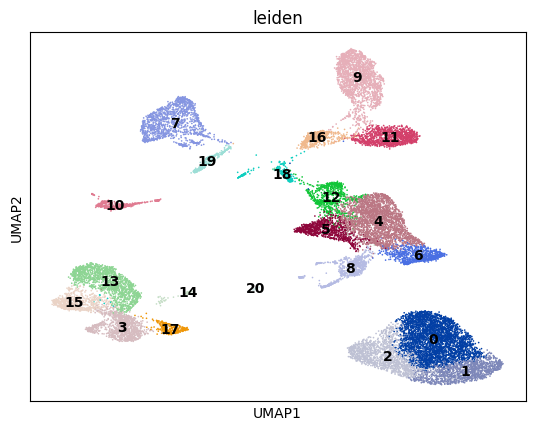

In [143]:
sc.tl.leiden(adata, resolution=0.6, n_iterations=-1, flavor='igraph', random_state=0)
sc.pl.umap(adata, color="leiden", legend_loc="on data")


In [144]:
markers = {
    # ─── FIGURE 1: Major cell types ───────────────────────────────────────────
    'Neutrophils':        ['S100a8', 'S100a9', 'Ly6g', 'Cxcr2'],
    'CD8_T_cells':        ['Cd8a', 'Cd8b1'],
    'Macrophages':        ['Cd68', 'F4/80', 'Adgre1', 'Mrc1'],
    'Fibroblasts':        ['Col1a1', 'Col1a2', 'Pdgfra'],
    'DC':                 ['Cd11c', 'H2-Ab1', 'Itgax'],
    'Cancer_cells':       ['Krt14', 'Krt5', 'Trp63'],
    'B_cells':            ['Cd19', 'Ms4a1'],
    'CD4_T_cells':        ['Cd4', 'Foxp3'],
    'Monocytes':          ['Ly6c2', 'Ccr2', 'Csf1r'],
    'NK_cells':           ['Nkg7', 'Klrb1c', 'Gzma'],
    'Endothelial_cells':  ['Pecam1', 'Cdh5', 'Eng'], }

In [145]:
umap_params = {
    'legend_loc': "on data",
    's': 30,
    'add_outline': False,
    'ncols': 3,
    'frameon': False
}

In [146]:
# Score cells for each cell type using marker genes
for cell_type, genes in markers.items():
    # Filter to genes that exist in the dataset
    valid_genes = [g for g in genes if g in adata.var_names]
    if len(valid_genes) > 0:
        sc.tl.score_genes(adata, valid_genes, score_name=f'{cell_type}_score')
        print(f"{cell_type}: {len(valid_genes)}/{len(genes)} genes found")
    else:
        print(f"{cell_type}: No genes found in dataset")

Neutrophils: 3/4 genes found
CD8_T_cells: 2/2 genes found
Macrophages: 2/4 genes found
Fibroblasts: 3/3 genes found
DC: 1/3 genes found
Cancer_cells: 3/3 genes found
B_cells: 1/2 genes found
CD4_T_cells: 2/2 genes found
Monocytes: 2/3 genes found
NK_cells: 3/3 genes found
Endothelial_cells: 2/3 genes found


In [147]:
# Calculate mean score per leiden cluster for each cell type
score_cols = [col for col in adata.obs.columns if col.endswith('_score')]
cluster_scores = adata.obs.groupby('leiden')[score_cols].mean()

# Find the cell type with highest score for each cluster
cluster_annotations = cluster_scores.idxmax(axis=1).str.replace('_score', '')
cluster_annotations.name = 'cell_type_annotation'

# Map annotations to cells
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)


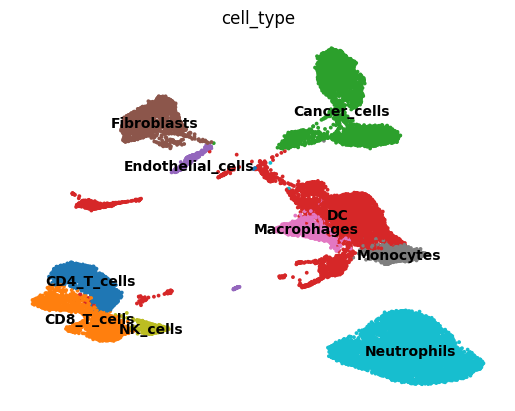

In [148]:
# Visualize the annotation on UMAP
sc.pl.umap(adata, color=['cell_type'], **umap_params)

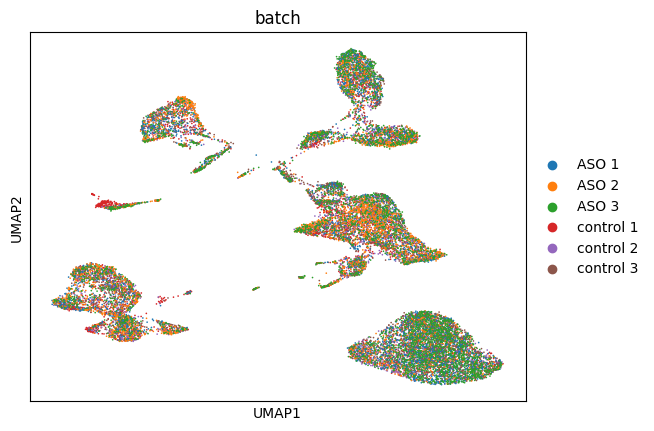

In [149]:
sc.pl.umap(adata, color=['batch'])

## Canonical Markers for validation

In [150]:
# marker_dict_ref = {
#     'CD4+ T': ['Cd4'],
#     'CD8+ T': ['Cd8a','Cd8b1', 'Nkg7'],
#     'Treg': ['Foxp3', 'Il2ra'],
#     'NK': ['Ncam1', 'Nkg7', 'Gnly', 'Klrd1'],
#     'B': ['Cd19', 'Cd79a', 'Ms4a1', 'Cd79b'],
#     'Myeloid': ['Cd68', 'Itgam', 'Cd14', 'Cd33'],
#     'Monocyte': ['Cd14', 'Fcgr3a', 'Lyz'],
#     'Macrophage': ['Cd68', 'Cd163', 'Mrc1', 'Adgre1', 'Csf1r', 'Ly86'],
#     'DC': ['Fcer1a', 'Clec9a', 'Irf8'],
#     'Plasma': ['Ighg1', 'Ighg2', 'Jchain', 'Xbp1'],
#     'neutrophil':['S100a9', 'S100a8', 'Ifitm2']
# }


marker_dict_ref = markers

UMAP: Neutrophils (markers: ['S100a8', 'S100a9', 'Ly6g'])


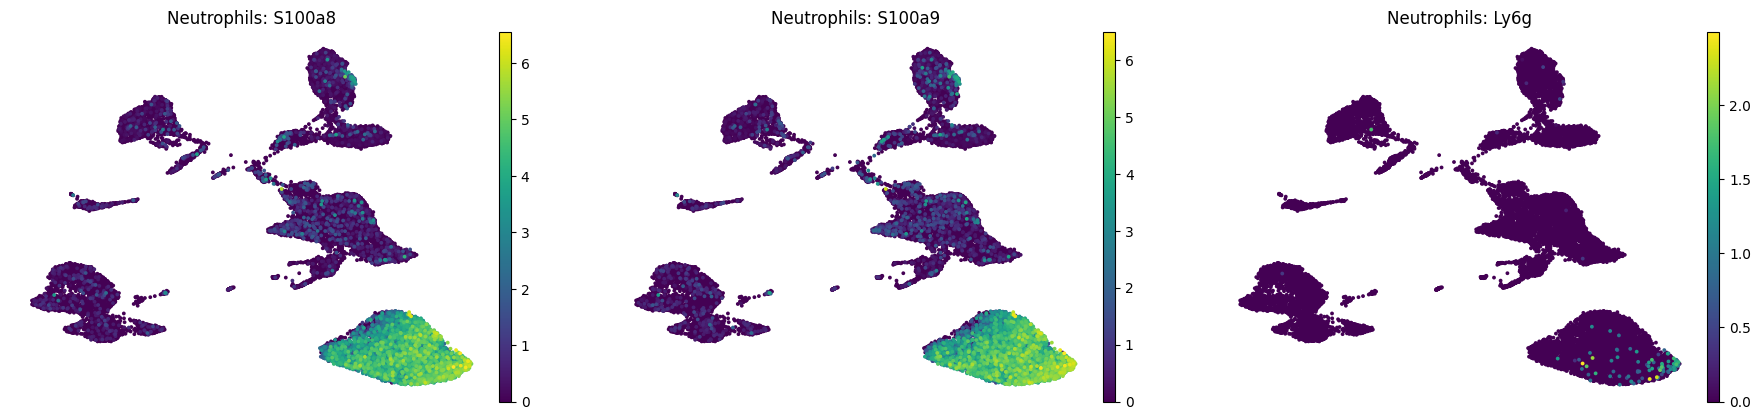

UMAP: CD8_T_cells (markers: ['Cd8a', 'Cd8b1'])


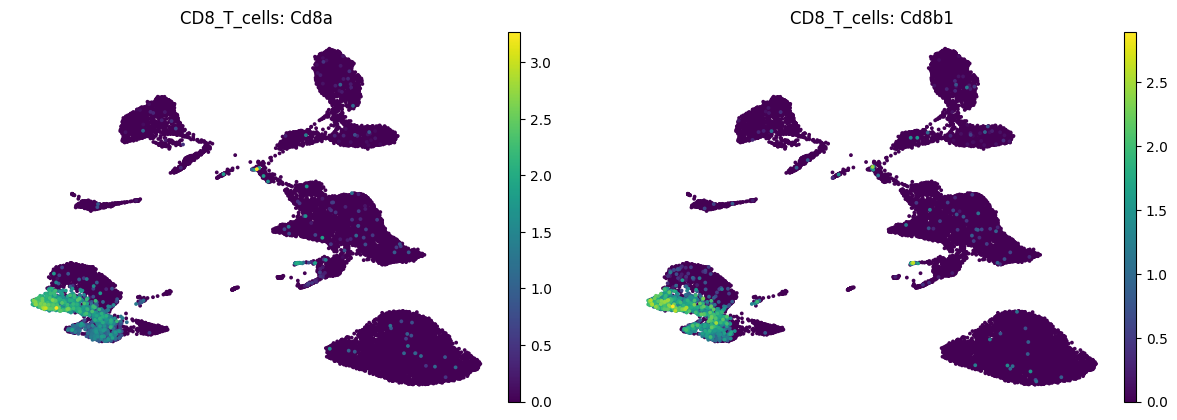

UMAP: Macrophages (markers: ['Adgre1', 'Mrc1'])


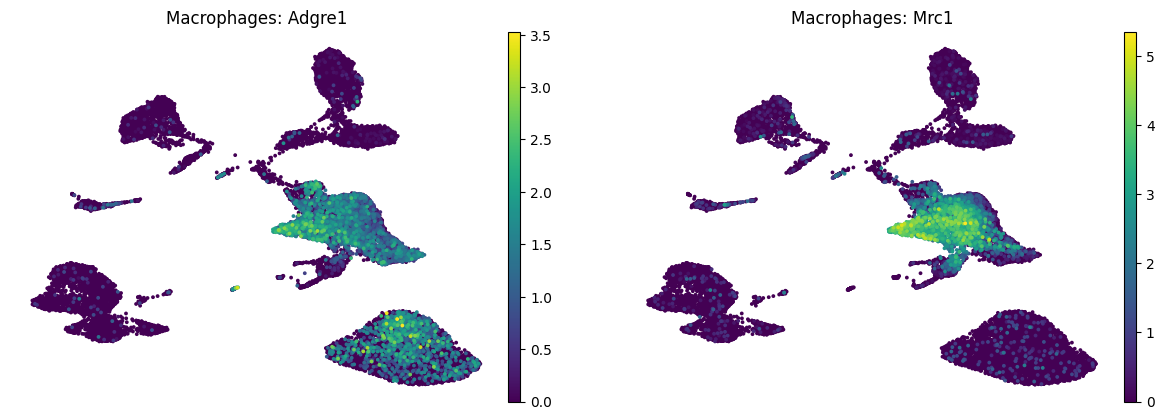

UMAP: Fibroblasts (markers: ['Col1a1', 'Col1a2', 'Pdgfra'])


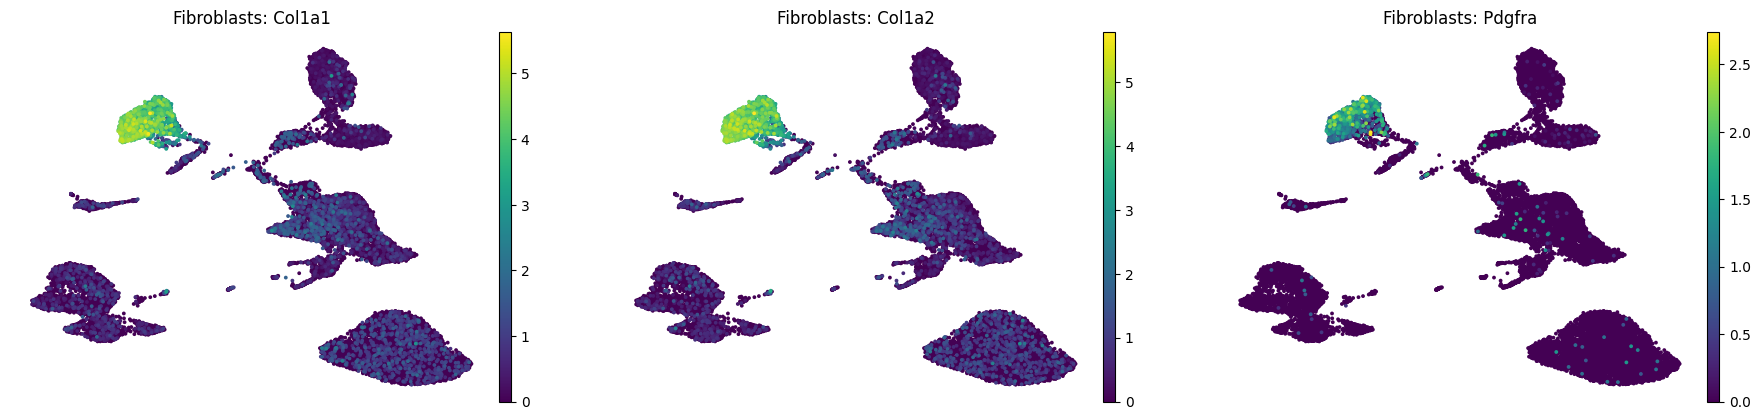

UMAP: DC (markers: ['H2-Ab1'])


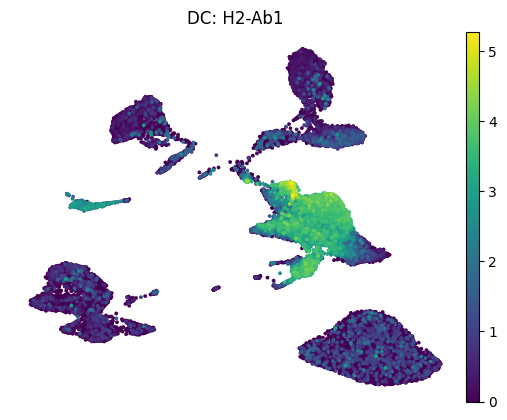

UMAP: Cancer_cells (markers: ['Krt14', 'Krt5', 'Trp63'])


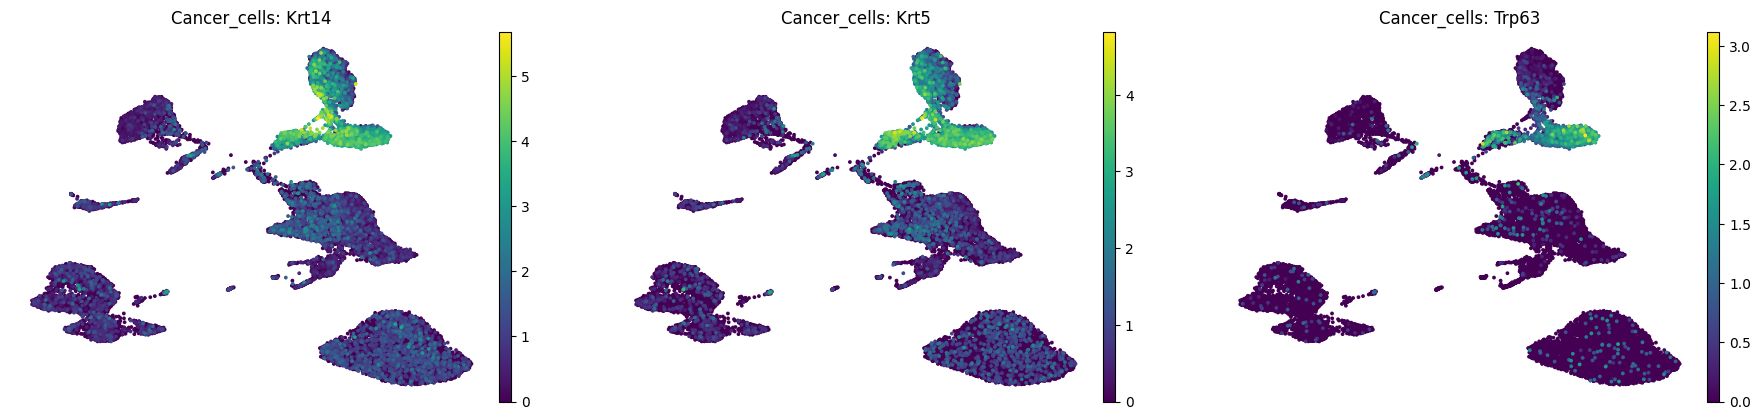

UMAP: B_cells (markers: ['Ms4a1'])


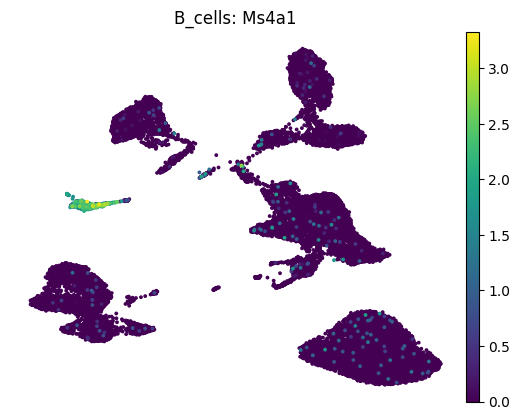

UMAP: CD4_T_cells (markers: ['Cd4', 'Foxp3'])


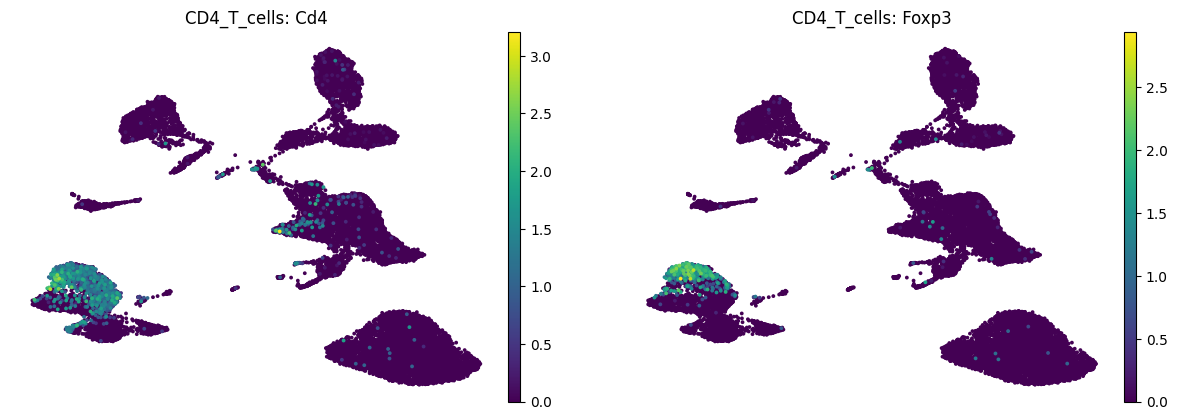

UMAP: Monocytes (markers: ['Ly6c2', 'Ccr2'])


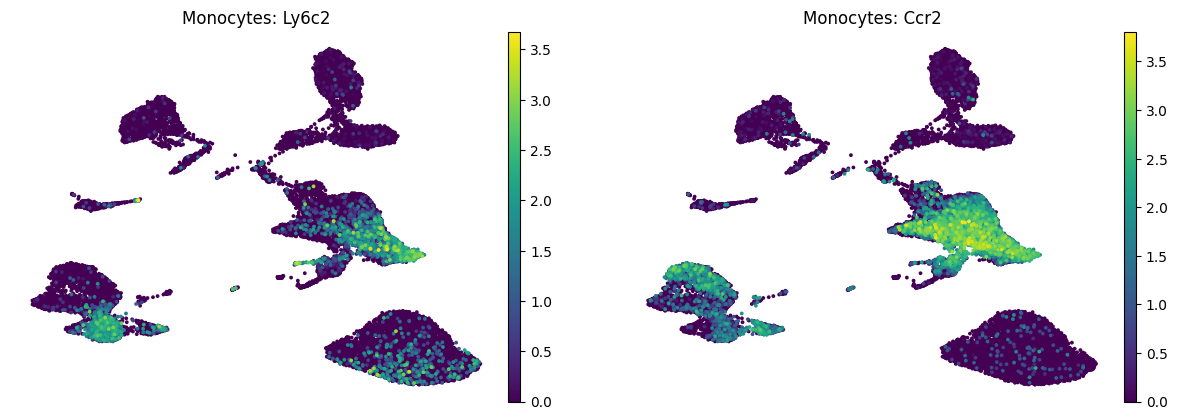

UMAP: NK_cells (markers: ['Nkg7', 'Klrb1c', 'Gzma'])


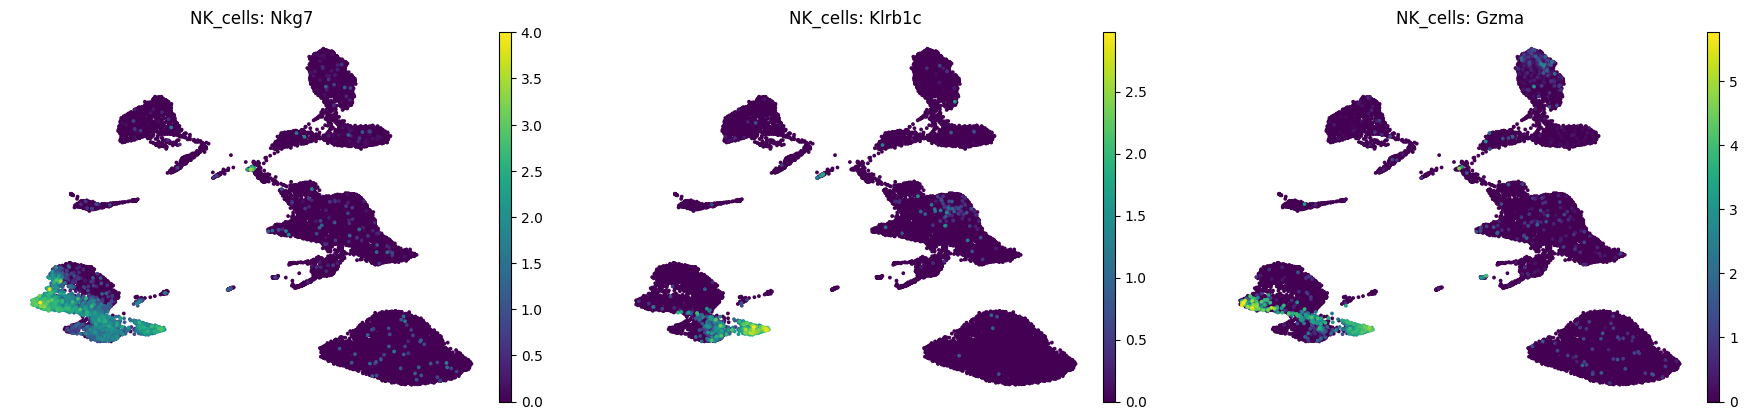

UMAP: Endothelial_cells (markers: ['Pecam1', 'Cdh5'])


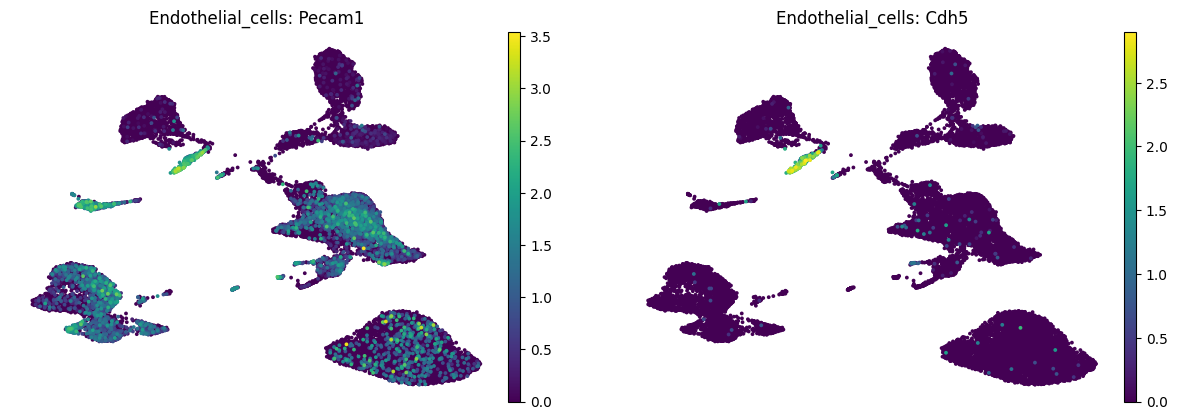

In [151]:
# Plot UMAP for each marker group in marker_dict_ref
for celltype, marker_list in marker_dict_ref.items():
    # Make sure markers exist in your adata.var_names (may want to filter missing ones)
    valid_markers = [gene for gene in marker_list if gene in adata.var_names]
    if not valid_markers:
        print(f"[Warning] No valid markers for {celltype}")
        continue
    print(f"UMAP: {celltype} (markers: {valid_markers})")
    sc.pl.umap(adata, color=valid_markers, title=[f"{celltype}: {gene}" for gene in valid_markers], **umap_params)

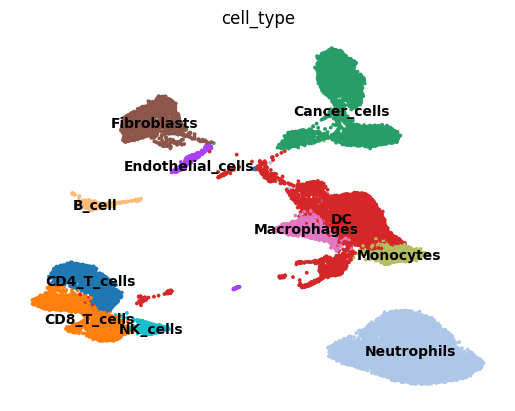

In [152]:
# Add new category before assigning
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories('B_cell')
adata.obs.loc[adata.obs['leiden'] == '10', 'cell_type'] = 'B_cell'


sc.pl.umap(adata, color=['cell_type'], **umap_params)

## subtypes

In [153]:
import numpy as np

Cancer_sub = {'Cancer_inflamed': ['Elif1', 'Dusp4', 'Tdrd7', 'Trafd1', 'Ppbp', 'Cxcl5', 'Trim25', 'Irf3', 'Irf2', 'Irf1',],
    'Cancer_mesenchymal': ['Lgals', 'Tns3', 'Col17a1', 'Ank3', 'Man1a', 'Efna5', 'Robo', 'Tnc', 'Itgb4', ],
    'Cancer_classical':   ['Hmgn1', 'Rack1', 'Eef1a1', 'Npm1', 'Ccnd1', 'Ptma'], }

# Cancer cell subtypes
adata_cancer = adata[adata.obs['cell_type'] == 'Cancer_cells'].copy()
if adata_cancer.n_obs > 0:
    sc.pp.pca(adata_cancer, n_comps=30)
    sc.pp.neighbors(adata_cancer)
    sc.tl.umap(adata_cancer)

    cancer_scores = []
    for subtype_name, genes in Cancer_sub.items():
        genes_present = [g for g in genes if g in adata_cancer.var_names]
        if not genes_present:
            continue

        score_key = f'Cancer_{subtype_name}_score'
        sc.tl.score_genes(adata_cancer, gene_list=genes_present, score_name=score_key)
        cancer_scores.append((subtype_name, score_key))

        if cancer_scores:
            score_matrix = np.vstack([adata_cancer.obs[score_key] for _, score_key in cancer_scores]).T
            best_idx = score_matrix.argmax(axis=1)
            best_subtypes = np.array([cancer_scores[i][0] for i in best_idx])
            adata_cancer.obs['cluster_annotation'] = best_subtypes
            adata.obs.loc[adata_cancer.obs_names, 'cluster_annotation'] = adata_cancer.obs['cluster_annotation']

        else:
            adata_cancer.obs['cluster_annotation'] = 'Unknown'
            adata.obs.loc[adata_cancer.obs_names, 'cluster_annotation'] = adata_cancer.obs['cluster_annotation']

#         marker_genes = sorted({g for genes in Cancer_sub.values() for g in genes if g in adata_cancer.var_names})
#         sc.pl.umap(
#             adata_cancer,
#             color=marker_genes + ['Cancer_subtype'],
#             title= [f"{subtype_name}: {gene}" for gene in genes],

#             # title='Cancer_cells subtypes and markers',
#             **umap_params,
#         )
    

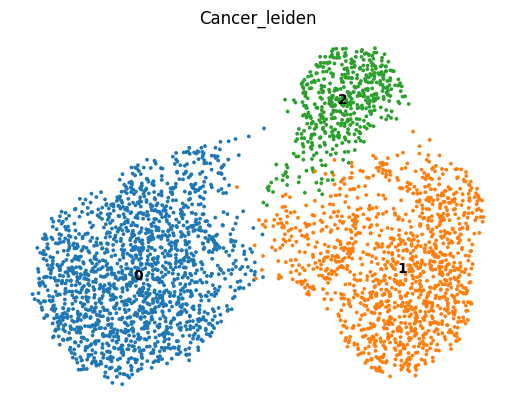

In [154]:
# Leiden clustering on cancer subset (~3–4 clusters)
sc.tl.leiden(
    adata_cancer,
    resolution=0.2,      # adjust (e.g. 0.3–0.6) to get 3–4 clusters
    key_added="Cancer_leiden",
)

sc.pl.umap(
    adata_cancer,
    color=['Cancer_leiden'],
    **umap_params,
)

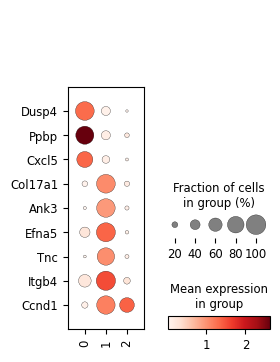

In [155]:
# Collect Cancer_sub genes that are actually present
cancer_dot_genes = [g for genes in Cancer_sub.values() for g in genes if g in adata_cancer.var_names]

# Dotplot of Cancer_sub genes across Leiden clusters
if len(cancer_dot_genes) > 0:
    sc.pl.dotplot(
        adata_cancer,
        var_names=cancer_dot_genes,
        groupby="Cancer_leiden",
        dendrogram=False,
        standard_scale=None,
        swap_axes=True,
    )

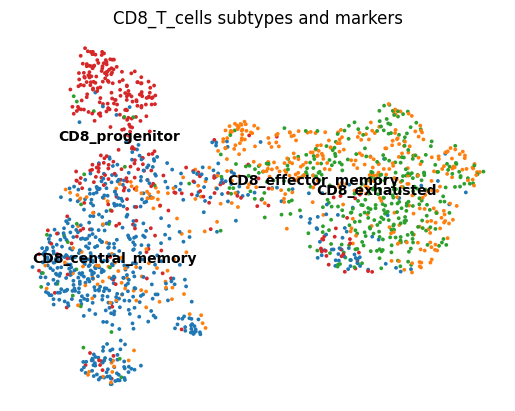

In [156]:
# CD8+ T cell subtypes
CD8_sub =   {  'CD8_progenitor':              ['Tcf7', 'Ccr7', 'Il7r', 'Ccnd3'],
    'CD8_exhausted':             ['Pdcd1', 'Havcr2', 'Lag3'],
    'CD8_central_memory':          ['Tcf7', 'Ccr7', 'Il7r', 'Il2rb',
                                    'Ifngr1'],
    'CD8_effector_memory':         ['Gzmb', 'Prf1', 'Nkg7'],
    'CD8_naive':                   ['Tcf7', 'Sell', 'Il7r', 'Ccr7'] }

adata_cd8 = adata[adata.obs['cell_type'] == 'CD8_T_cells'].copy()
if adata_cd8.n_obs > 0:
    sc.pp.pca(adata_cd8, n_comps=30)
    sc.pp.neighbors(adata_cd8)
    sc.tl.umap(adata_cd8)

    cd8_scores = []
    for subtype_name, genes in CD8_sub.items():
        genes_present = [g for g in genes if g in adata_cd8.var_names]
        if not genes_present:
            continue

        score_key = f'CD8_{subtype_name}_score'
        sc.tl.score_genes(adata_cd8, gene_list=genes_present, score_name=score_key)
        cd8_scores.append((subtype_name, score_key))

        if cd8_scores:
            score_matrix = np.vstack([adata_cd8.obs[score_key] for _, score_key in cd8_scores]).T
            best_idx = score_matrix.argmax(axis=1)
            best_subtypes = np.array([cd8_scores[i][0] for i in best_idx])
            adata_cd8.obs['cluster_annotation'] = best_subtypes
            adata.obs.loc[adata_cd8.obs_names, 'cluster_annotation'] = adata_cd8.obs['cluster_annotation']
        else:
            adata_cd8.obs['cluster_annotation'] = 'Unknown'
            adata.obs.loc[adata_cd8.obs_names, 'cluster_annotation'] = adata_cd8.obs['cluster_annotation']

        marker_genes = sorted({g for genes in CD8_sub.values() for g in genes if g in adata_cd8.var_names})
        
    sc.pl.umap(
        adata_cd8,
        # color=marker_genes + ['cluster_annotation'],
        color=['cluster_annotation'],
        title='CD8_T_cells subtypes and markers',
        **umap_params,
    )

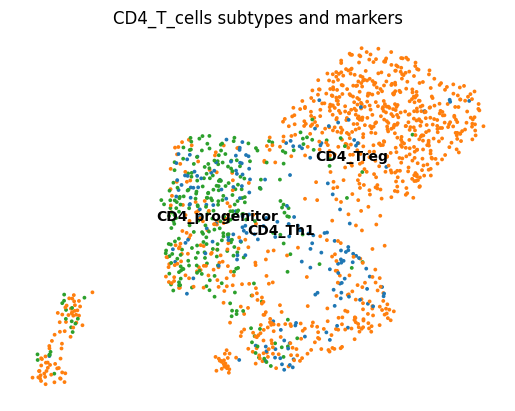

In [157]:
# CD4+ T cell subtypes
CS4_sub = {'CD4_progenitor':  ['Cd4', 'Tcf7', 'Ccr7'],
    'CD4_Th1':                     ['Cd4', 'Cda4', 'Eea1', 'Bcl2',
                                    'Ccnd3', 'Ctla4'],
    'CD4_Treg':                        ['Foxp3', 'Il2ra', 'Ctla4', 'Ccnd3',
                                    'Il7r'],}

adata_cd4 = adata[adata.obs['cell_type'] == 'CD4_T_cells'].copy()
if adata_cd4.n_obs > 0:
    sc.pp.pca(adata_cd4, n_comps=30)
    sc.pp.neighbors(adata_cd4)
    sc.tl.umap(adata_cd4)

    cd4_scores = []
    for subtype_name, genes in CS4_sub.items():
        genes_present = [g for g in genes if g in adata_cd4.var_names]
        if not genes_present:
            continue

        score_key = f'CD4_{subtype_name}_score'
        sc.tl.score_genes(adata_cd4, gene_list=genes_present, score_name=score_key)
        cd4_scores.append((subtype_name, score_key))

        if cd4_scores:
            score_matrix = np.vstack([adata_cd4.obs[score_key] for _, score_key in cd4_scores]).T
            best_idx = score_matrix.argmax(axis=1)
            best_subtypes = np.array([cd4_scores[i][0] for i in best_idx])
            adata_cd4.obs['cluster_annotation'] = best_subtypes
            adata.obs.loc[adata_cd4.obs_names, 'cluster_annotation'] = adata_cd4.obs['cluster_annotation']
        else:
            adata_cd4.obs['cluster_annotation'] = 'Unknown'
            adata.obs.loc[adata_cd4.obs_names, 'cluster_annotation'] = adata_cd4.obs['cluster_annotation']

        marker_genes = sorted({g for genes in CS4_sub.values() for g in genes if g in adata_cd4.var_names})
        
    sc.pl.umap(
        adata_cd4,
        # color=marker_genes + ['cluster_annotation'],
        color=['cluster_annotation'],
        title='CD4_T_cells subtypes and markers',
        **umap_params,
    )

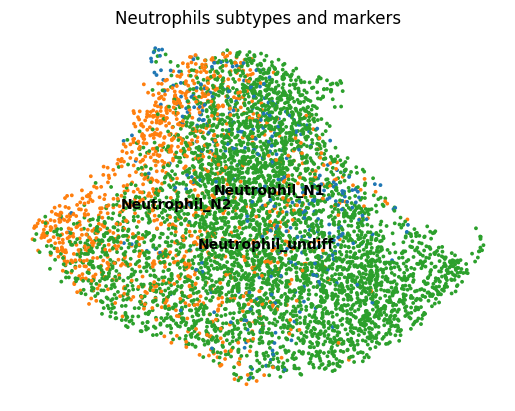

In [158]:
# Neutrophil subtypes
Neu_sub = {'Neutrophil_N1':     ['Arg2', 'Olr1', 'Tgfb1', 'Cxcr2'],
    'Neutrophil_N2':      ['Arg2', 'Ccl3', 'Nos2', 'Cxcr2'],
    'Neutrophil_undiff': ['S100a8', 'S100a9']}

# 'Arg2', 'Olr1', 'Tgfb1', 'Cxcr2', 'Nos2'

adata_neu = adata[adata.obs['cell_type'] == 'Neutrophils'].copy()
if adata_neu.n_obs > 0:
    sc.pp.pca(adata_neu, n_comps=30)
    sc.pp.neighbors(adata_neu)
    sc.tl.umap(adata_neu)
    neu_scores = []
    for subtype_name, genes in Neu_sub.items():
        genes_present = [g for g in genes if g in adata_neu.var_names]
        if not genes_present:
            continue

        score_key = f'Neu_{subtype_name}_score'
        sc.tl.score_genes(adata_neu, gene_list=genes_present, score_name=score_key)
        neu_scores.append((subtype_name, score_key))

        if neu_scores:
            score_matrix = np.vstack([adata_neu.obs[score_key] for _, score_key in neu_scores]).T
            best_idx = score_matrix.argmax(axis=1)
            best_subtypes = np.array([neu_scores[i][0] for i in best_idx])
            adata_neu.obs['cluster_annotation'] = best_subtypes
            adata.obs.loc[adata_neu.obs_names, 'cluster_annotation'] = adata_neu.obs['cluster_annotation']
        else:
            adata_neu.obs['cluster_annotation'] = 'Unknown'
            adata.obs.loc[adata_neu.obs_names, 'cluster_annotation'] = adata_neu.obs['cluster_annotation']

        marker_genes = sorted({g for genes in Neu_sub.values() for g in genes if g in adata_neu.var_names})
        
        # sc.pl.umap(
        #     adata_neu,
        #     color=marker_genes + ['cluster_annotation'],
        #     # color= ['cluster_annotation'],
        #     title='Neutrophils subtypes and markers',
        #     **umap_params,
        # )
            
    sc.pl.umap(
        adata_neu,
        # color=marker_genes + ['cluster_annotation'],
        color= ['cluster_annotation'],
        title='Neutrophils subtypes and markers',
        **umap_params,
    )

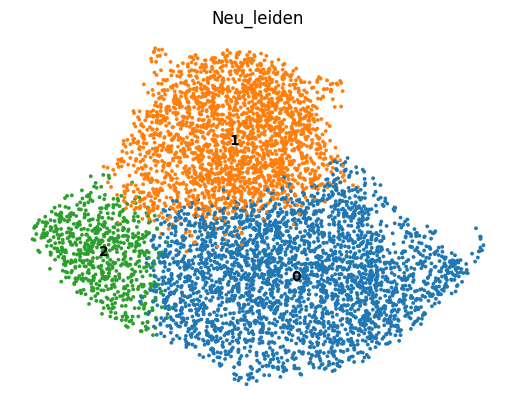

In [159]:
# Leiden clustering on cancer subset (~3–4 clusters)
sc.tl.leiden(
    adata_neu,
    resolution=0.2,      # adjust (e.g. 0.3–0.6) to get 3–4 clusters
    key_added="Neu_leiden",
)

sc.pl.umap(
    adata_neu,
    color=['Neu_leiden'],
    **umap_params,
)

In [160]:
adata_neu

AnnData object with n_obs × n_vars = 6024 × 2500
    obs: 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Neutrophils_score', 'CD8_T_cells_score', 'Macrophages_score', 'Fibroblasts_score', 'DC_score', 'Cancer_cells_score', 'B_cells_score', 'CD4_T_cells_score', 'Monocytes_score', 'NK_cells_score', 'Endothelial_cells_score', 'cell_type', 'cluster_annotation', 'Neu_Neutrophil_N1_score', 'Neu_Neutrophil_N2_score', 'Neu_Neutrophil_undiff_score', 'Neu_leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'batch_colors', 'cluster_annotation_colors', 'Neu_leiden', 'Neu_leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectiviti

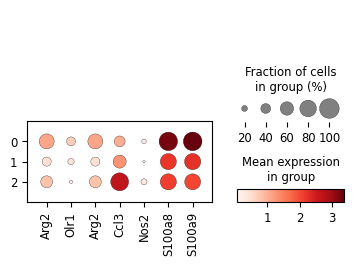

In [161]:
# Collect Cancer_sub genes that are actually present
Neu_sub = {'Neutrophil_N1':     ['Arg2', 'Olr1', 'Tgfb1', 'Cxcr2'],
    'Neutrophil_N2':      ['Arg2', 'Ccl3', 'Nos2', 'Cxcr2'],
    'Neutrophil_undiff': ['S100a8', 'S100a9']}
# Neu_dot_genes = [g for genes in Neu_sub for g in genes if g in adata_neu.var_names]
Neu_sub = [g for genes in Neu_sub.values() for g in genes if g in adata_neu.var_names]

# Neu_sub = ['Arg2', 'Olr1', 'Tgfb1', 'Cxcr2', 'Nos2']

# Dotplot of Cancer_sub genes across Leiden clusters
if len(cancer_dot_genes) > 0:
    sc.pl.dotplot(
        adata_neu,
        var_names=Neu_sub,
        groupby="Neu_leiden",
    )

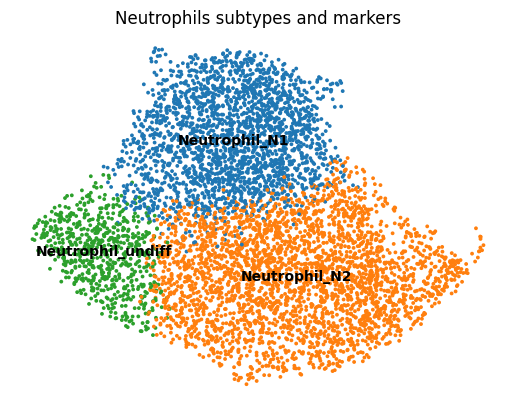

In [162]:
adata_neu.obs.loc[adata_neu.obs['Neu_leiden'] == '0', 'cluster_annotation'] = 'Neutrophil_N2'
adata_neu.obs.loc[adata_neu.obs['Neu_leiden'] == '2', 'cluster_annotation'] = 'Neutrophil_undiff'
adata_neu.obs.loc[adata_neu.obs['Neu_leiden'] == '1', 'cluster_annotation'] = 'Neutrophil_N1'

adata.obs.loc[adata_neu.obs_names, 'cluster_annotation'] = adata_neu.obs['cluster_annotation']

sc.pl.umap(
    adata_neu,
    color= ['cluster_annotation'],
    title='Neutrophils subtypes and markers',
    **umap_params,
)

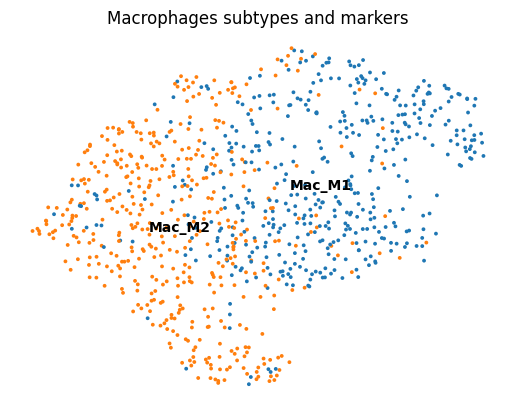

In [163]:
# Macrophage subtypes

Mac_sub = {
    'Mac_M2': ['Mrc1', 'Cd163', 'Adgre1', ],
    'Mac': ['Lgals3', 'Cd68', 'Itgax'],
    'Mac_M1': ['H2-Ab1', 'Csf1r', 'Ccr2', 'Arg1']
}

adata_mac = adata[adata.obs['cell_type'] == 'Macrophages'].copy()
if adata_mac.n_obs > 0:
    sc.pp.pca(adata_mac, n_comps=30)
    sc.pp.neighbors(adata_mac)
    sc.tl.umap(adata_mac)

    mac_scores = []
    for subtype_name, genes in Mac_sub.items():
        genes_present = [g for g in genes if g in adata_mac.var_names]
        if not genes_present:
            continue

        score_key = f'Mac_{subtype_name}_score'
        sc.tl.score_genes(adata_mac, gene_list=genes_present, score_name=score_key)
        mac_scores.append((subtype_name, score_key))

        if mac_scores:
            score_matrix = np.vstack([adata_mac.obs[score_key] for _, score_key in mac_scores]).T
            best_idx = score_matrix.argmax(axis=1)
            best_subtypes = np.array([mac_scores[i][0] for i in best_idx])
            adata_mac.obs['cluster_annotation'] = best_subtypes
            adata.obs.loc[adata_mac.obs_names, 'cluster_annotation'] = adata_mac.obs['cluster_annotation']
        else:
            adata_mac.obs['cluster_annotation'] = 'Unknown'
            adata.obs.loc[adata_mac.obs_names, 'cluster_annotation'] = adata_mac.obs['cluster_annotation']

        marker_genes = sorted({g for genes in Mac_sub.values() for g in genes if g in adata_mac.var_names})
        
    sc.pl.umap(
        adata_mac,
        # color=marker_genes + ['cluster_annotation'],
        color= ['cluster_annotation'],
        title='Macrophages subtypes and markers',
        **umap_params,
    )

In [164]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
Neutrophil_N2          3094
Neutrophil_N1          2254
Cancer_inflamed        1653
Cancer_mesenchymal      952
CD4_Treg                929
Cancer_classical        825
Neutrophil_undiff       676
CD8_central_memory      585
Mac_M1                  461
Mac_M2                  454
CD8_effector_memory     439
CD8_exhausted           367
CD8_progenitor          336
CD4_progenitor          290
CD4_Th1                 186
Name: count, dtype: int64

In [ ]:
batch_pct = adata.obs['batch'].value_counts(normalize=True) * 100
batch_pct_df = batch_pct.reset_index()
batch_pct_df.columns = ['batch', 'percentage']

In [165]:
adata.write("Moc_ref_cluster_annotated.h5ad")

# Annotate tumor by infercnv

In [166]:
aa
# not exist
adata.var['gene_ids']

NameError: name 'aa' is not defined

In [ ]:
import io

# 1. Load the GTF file (The "Local Replacement")
# Replace with the actual path to your GRCm38 genes.gtf
gtf_path = "/ix1/ylee/Yifan_Zhang/Cellranger_ref/refdata-gex-GRCm39-2024-A/genes_gtf/genes.gtf"

# Define the columns for a standard GTF
cols = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]

# Read the file, skipping the header lines (starting with #)
gtf_df = pd.read_csv(gtf_path, sep="\t", comment="#", names=cols, low_memory=False)

# 2. Filter for 'gene' entries to get the boundaries
gtf_genes = gtf_df[gtf_df["feature"] == "gene"].copy()

# 3. Extract the Gene Symbol from the 'attribute' column 
# (This regex looks for 'gene_name "Symbol";')
gtf_genes["gene_symbol"] = gtf_genes["attribute"].str.extract('gene_name "([^"]+)"')

# 4. Create the mapping table
mapping_table = gtf_genes[["gene_symbol", "chr", "start", "end"]].dropna().drop_duplicates("gene_symbol")
mapping_table.set_index("gene_symbol", inplace=True)

# 5. Inject into your AnnData for infercnvpy
adata.var['chromosome'] = adata.var_names.map(mapping_table['chr'])
adata.var['start'] = adata.var_names.map(mapping_table['start'])
adata.var['end'] = adata.var_names.map(mapping_table['end'])

# 6. Cleanup (Remove genes that didn't find a match in the GTF)
adata = adata[:, adata.var['chromosome'].notna()].copy()

In [ ]:
adata.var.loc[:, ["gene_ids", "chromosome", "start", "end"]].head()

In [ ]:
adata.obs['cell_type'].cat.categories.tolist()

In [ ]:
import infercnvpy as cnv
# We provide all immune cell types as "normal cells".
cnv.tl.infercnv(
    adata,
    reference_key="cell_type",
    window_size=250,
    # reference_cat=adata.obs['cluster_annotation'].cat.categories.tolist(),
    reference_cat=['CD4_T_cells',
                    'CD8_T_cells',
                    'DC',
                    'Macrophages',
                  'Neutrophils']
)

In [ ]:
cnv.pl.chromosome_heatmap(adata, groupby="cluster_annotation")

In [ ]:
cnv.tl.pca(adata, n_comps=5)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)

In [ ]:
cnv.pl.chromosome_heatmap(adata, groupby="cnv_leiden")

In [ ]:
cnv.tl.umap(adata)
cnv.tl.cnv_score(adata)

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="cell_type", ax=ax3)

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 11), gridspec_kw={"wspace": 0.5})
ax4.axis("off")
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
sc.pl.umap(adata, color="cell_type", ax=ax3)

In [ ]:
adata.obs["cnv_status"] = "normal"
adata.obs.loc[adata.obs["cnv_leiden"].isin(["19", "6", '23']), "cnv_status"] = (
    "tumor"
)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.5})
cnv.pl.umap(adata, color="cnv_status", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_status", ax=ax2)